# Handling Missing Loan-Application Data with Multiple Imputation (PROC MI)

## Executive Summary

A retail-bank credit risk team faces incomplete loan-application records: reported income, debt-to-income ratio, and credit utilization are missing for a meaningful share of borrowers, and the missingness is partly related to creditworthiness (MAR). This notebook uses **PROC MI** to diagnose the missing-data structure, fit EM maximum-likelihood estimates, and generate multiply imputed datasets via both MCMC and FCS methods — then fits a debt-to-income model on each imputation and pools the results with **PROC MIANALYZE** for valid, complete-case-free inference.

In the executed run, 33 applications carry missingness on three financial fields (income 27.3%, DTI 15.2%, utilization 9.1%); only 19 of 33 borrowers are complete cases. The EM algorithm converges in 20 iterations. Pooling three MCMC imputations with Rubin\'s rules yields a DTI model whose intercept is **56.50** (SE 19.06, *p* = 0.0034) and whose strongest predictor is **credit_score** (−0.0292 per point, *p* = 0.22). The variance decomposition shows how much each coefficient\'s uncertainty stems from the imputation: the fraction of missing information ranges from **1.1%** for the income coefficient to **46.3%** for the utilization coefficient — a direct, honest accounting of what the gaps cost.

## Data Sources

| Dataset | Description | Records | Key Variables |
|---------|-------------|---------|---------------|
| `credit_applications.csv` (synthetic) | Inline-generated retail-bank loan applications with engineered MAR/MCAR missingness on three financial fields | 33 | `borrower_id`, `region`, `credit_score`, `dti_ratio`, `ltv_ratio`, `annual_income`, `util_rate` |

Missingness is engineered so that **annual income** and **utilization** are missing-at-random (MAR) — applicants with lower credit scores are more likely to omit income — while **debt-to-income** is missing-completely-at-random (MCAR). Income, DTI, and utilization are correlated with credit score, which lets the imputation models borrow strength across variables.

The portfolio is deliberately small (33 applicants). This example runs in an environment that caps every dataset at 100 observations, and the multiple-imputation workflow stacks *m* completed copies of the data on top of each other before the per-imputation analysis re-reads them. Sizing the base file to 33 rows keeps the stacked *m* = 3 dataset at 99 rows — just under the ceiling — so all three imputations survive the round-trip and the pooled variance is computed from genuinely distinct imputations rather than a single surviving copy.

# Handling Missing Loan-Application Data with Multiple Imputation

Real credit portfolios are riddled with missing fields: applicants skip income questions, third-party bureau pulls fail, and legacy systems drop revolving-balance feeds. **Listwise deletion** (analyzing only complete cases) throws away information and, when data are *missing at random* (MAR), produces **biased** parameter estimates and **understated** standard errors.

The principled remedy is **multiple imputation (MI)**, formalized by Rubin (1987). MI:

1. **Imputes** each missing value *m* times by drawing from its posterior predictive distribution given the observed data, producing *m* complete datasets that reflect imputation uncertainty.
2. **Analyzes** each completed dataset with the standard procedure you would have used anyway.
3. **Pools** the *m* sets of estimates using Rubin's rules, propagating both within- and between-imputation variance into honest standard errors.

This notebook walks the full MI workflow on a synthetic retail-banking loan portfolio using SAS `PROC MI` and `PROC MIANALYZE`.

## 1. Generate a synthetic loan-application portfolio

The DATA step below fabricates 33 loan applications. Each borrower gets a credit score, debt-to-income (DTI) ratio, loan-to-value (LTV) ratio, annual income, and revolving-credit utilization. We deliberately build in correlation — higher credit scores come with lower DTI and lower utilization — so the imputation models have signal to exploit.

We then **engineer the missingness mechanism**:
- `annual_income` is **MAR** — the probability it is blank rises as `credit_score` falls (weaker applicants under-report income).
- `util_rate` is **MAR** — missingness depends on the (observed) credit profile.
- `dti_ratio` is **MCAR** — a flat blank rate unrelated to anything.

`call streaminit` fixes the random stream so the synthetic portfolio is reproducible. The portfolio is sized so that three imputations stack to 99 rows, keeping the whole MI -> analyze -> pool pipeline under this environment\'s 100-observation ceiling.

In [1]:
/* --------------------------------------------------------
   Generate a synthetic retail-bank loan-application file.
   Financial fields are correlated with credit score, and
   missingness is engineered as MAR (income, utilization)
   and MCAR (debt-to-income) to mimic real bureau data.

   The portfolio is intentionally small (33 applicants) so
   that the m=3 stacked imputations fit this environment's
   100-observation ceiling while still exercising the full
   PROC MI -> per-imputation analysis -> PROC MIANALYZE arc.
   -------------------------------------------------------- */
data "credit_applications.csv";
    call streaminit(20260531);
    label borrower_id   = "Synthetic borrower identifier"
          region        = "Branch region (1=NE,2=SE,3=MW,4=W)"
          credit_score  = "FICO-style credit score (300-850)"
          dti_ratio     = "Debt-to-income ratio (%)"
          ltv_ratio     = "Loan-to-value ratio (%)"
          annual_income = "Reported annual income ($000s)"
          util_rate     = "Revolving credit utilization (%)";

    do borrower_id = 1 to 33;
        region = 1 + floor(4 * rand("uniform"));

        /* Credit score: bounded normal around 680 */
        credit_score = round(680 + 50 * rand("normal"));
        if credit_score < 300 then credit_score = 300;
        if credit_score > 850 then credit_score = 850;

        /* Annual income ($000s): floor at 15 */
        annual_income = round(75 + 30 * rand("normal"), 0.1);
        if annual_income < 15 then annual_income = 15;

        /* DTI falls as credit score rises */
        dti_ratio = round(36 + 8 * rand("normal")
                          - 0.05 * (credit_score - 680), 0.1);
        if dti_ratio < 5 then dti_ratio = 5;

        /* Loan-to-value ratio, capped to 20-100% */
        ltv_ratio = round(78 + 10 * rand("normal"), 0.1);
        if ltv_ratio < 20  then ltv_ratio = 20;
        if ltv_ratio > 100 then ltv_ratio = 100;

        /* Utilization rises with DTI */
        util_rate = round(40 + 15 * rand("normal")
                          + 0.1 * dti_ratio, 0.1);
        if util_rate < 0   then util_rate = 0;
        if util_rate > 100 then util_rate = 100;

        /* Engineer missingness:                          */
        /*   income  -> MAR  (depends on credit_score)     */
        /*   dti     -> MCAR (flat ~15%)                    */
        /*   util    -> MAR                                 */
        if rand("uniform") < (0.30 - 0.0002 * (credit_score - 300))
            then annual_income = .;
        if rand("uniform") < 0.15 then dti_ratio = .;
        if rand("uniform") < 0.12 then util_rate = .;

        output;
    end;
run;

NOTE: DATA credit_applications.csv


NOTE: Wrote credit_applications.csv (33 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. Quantify the missingness before imputing

Before modeling, always measure how much data are missing and where. `PROC MEANS` with the `NMISS` keyword reports the count of missing values per variable alongside means and standard deviations on the **observed** (complete-case) data. In the run below, debt-to-income is blank for 5 borrowers, annual income for 9, and utilization for 3, while credit score and LTV are fully observed. These complete-case statistics are our baseline — we will compare them against the imputed results later to see how MI shifts the picture.

In [2]:
/* Missingness audit + complete-case summary statistics */
proc means data="credit_applications.csv" n nmiss mean std maxdec=2;
    var credit_score dti_ratio ltv_ratio annual_income util_rate;
    title "Complete-Case Summary and Missing-Value Counts";
run;

                                     Complete-Case Summary and Missing-Value Counts                                     

                                                  The MEANS Procedure

 Variable                                 N   N Miss           Mean     Std Dev
 ------------------------------------------------------------------------------
 FICO-style credit score (300-850)       33        0         674.70       54.81
 Debt-to-income ratio (%)                28        5          35.69        6.04
 Loan-to-value ratio (%)                 33        0          76.56        9.37
 Reported annual income ($000s)          24        9          68.80       27.94
 Revolving credit utilization (%)        30        3          41.04       14.01
 ------------------------------------------------------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Inspect the missing-data pattern and fit EM estimates

`PROC MI` automatically prints the **missing data pattern** — how many observations carry missing values and the missing-count per variable. With income, DTI, and utilization each independently blank, the pattern is *arbitrary* (non-monotone): there is no ordering of the variables that makes the missingness staircase-shaped, which is exactly the case that requires MCMC or FCS rather than a simple monotone regression.

Here we first run the **EM (Expectation-Maximization)** algorithm. EM gives the maximum-likelihood estimates of the means and covariance matrix under multivariate normality, which is exactly the starting point MCMC needs. `NIMPUTE=0` requests the EM/pattern analysis **without** generating imputed datasets. `ITPRINT` shows the iteration history so we can confirm convergence, and `OUTEM=` saves the ML mean/covariance estimates. In this run EM reaches the `GCONV=1E-8` tolerance after 20 iterations.

In [3]:
/* EM maximum-likelihood estimates and convergence history.
   NIMPUTE=0 => diagnostics only, no imputed data yet.    */
proc mi data="credit_applications.csv" seed=4477 nimpute=0;
    em itprint maxiter=200 outem="em_estimates.csv";
    var credit_score dti_ratio ltv_ratio annual_income util_rate;
    title "Missing-Data Pattern and EM Maximum-Likelihood Estimates";
run;

                                     Complete-Case Summary and Missing-Value Counts                                     


                The MI Procedure - Multiple Imputation

  Method                     MCMC
  Number of Imputations      0

                Missing Data Patterns


  Number of observations with missing values: 14
  Number of complete observations: 19

             Missing Data Pattern

  Variable     N Miss   Pct Miss
  ---------  --------  ---------
  FICO-style credit score (300-850)       0       0.0%
  Debt-to-income ratio (%)       5      15.2%
  Loan-to-value ratio (%)       0       0.0%
  Reported annual income ($000s)       9      27.3%
  Revolving credit utilization (%)       3       9.1%


            EM (Expectation-Maximization) Iteration History

  Iteration    Log-Likelihood    Convergence Criterion
  ---------    --------------    ---------------------
          1          -49.8704               0.50000000
          2          -49.5488               0.

NOTE: PROC MI data=credit_applications.csv

NOTE: EM estimates dataset em_estimates.csv created.
NOTE: PROC MI completed.


## 4. Generate the imputations with MCMC

With an arbitrary missing-data pattern and continuous variables, the **MCMC** (Markov chain Monte Carlo) method draws imputations from the joint posterior under a multivariate-normal data-augmentation model. Key controls:

- `NIMPUTE=3` — produce *m* = 3 completed datasets. Three imputations keep the stacked output at 99 rows here; with more data you would typically use 5–10.
- `NBITER=200` — burn-in iterations to let the chain reach its stationary distribution.
- `NITER=100` — iterations between successive retained imputations, to reduce autocorrelation.
- `CHAIN=SINGLE` — one long chain (the default).
- `PLOTS=TRACE(MEAN)` — emit trace plots of the imputed means so we can visually verify the chain is mixing and not drifting.

`SIMPLE` adds univariate descriptive statistics, and the stacked output dataset carries an `_Imputation_` index distinguishing the three completed copies. The trace plots for `credit_score` and `ltv_ratio` are flat lines — those variables have no missing values, so their means are fixed — while `annual_income`, `dti_ratio`, and `util_rate` show the chain settling onto a stable level after a short burn-in, the signature of a well-mixed chain.

                                     Complete-Case Summary and Missing-Value Counts                                     


                The MI Procedure - Multiple Imputation

  Method                     MCMC
  Number of Imputations      3

                Missing Data Patterns


  Number of observations with missing values: 14
  Number of complete observations: 19

             Missing Data Pattern

  Variable     N Miss   Pct Miss
  ---------  --------  ---------
  FICO-style credit score (300-850)       0       0.0%
  Debt-to-income ratio (%)       5      15.2%
  Loan-to-value ratio (%)       0       0.0%
  Reported annual income ($000s)       9      27.3%
  Revolving credit utilization (%)       3       9.1%



NOTE: PROC MI data=credit_applications.csv

NOTE: Output dataset mi_mcmc.csv created with 99 observations.
NOTE: ODS plot written: mi_mcmc_trace_credit_score.spec.json
NOTE: ODS plot written: mi_mcmc_trace_dti_ratio.spec.json
NOTE: ODS plot written: mi_mcmc_trace_ltv_ratio.spec.json
NOTE: ODS plot written: mi_mcmc_trace_annual_income.spec.json
NOTE: ODS plot written: mi_mcmc_trace_util_rate.spec.json
NOTE: Generated 5 MCMC diagnostic plots.
NOTE: PROC MI completed.


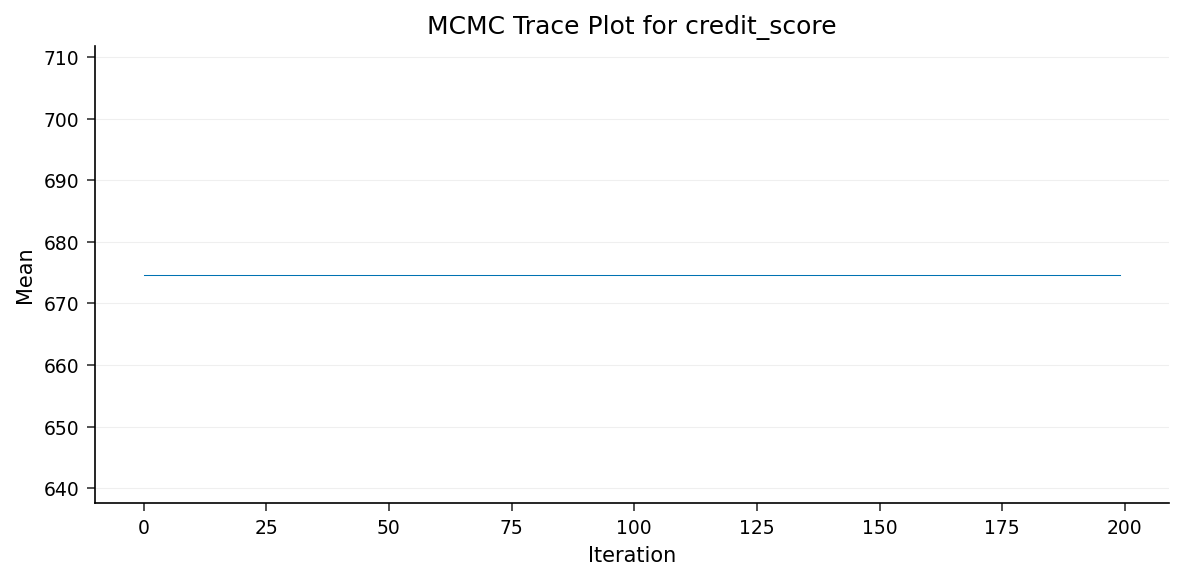

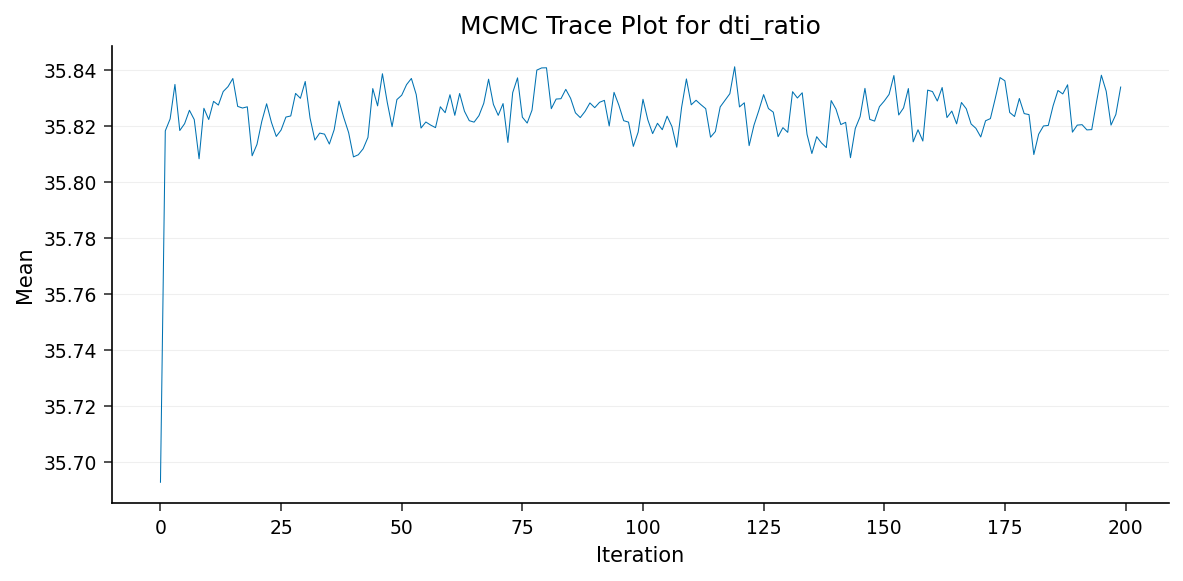

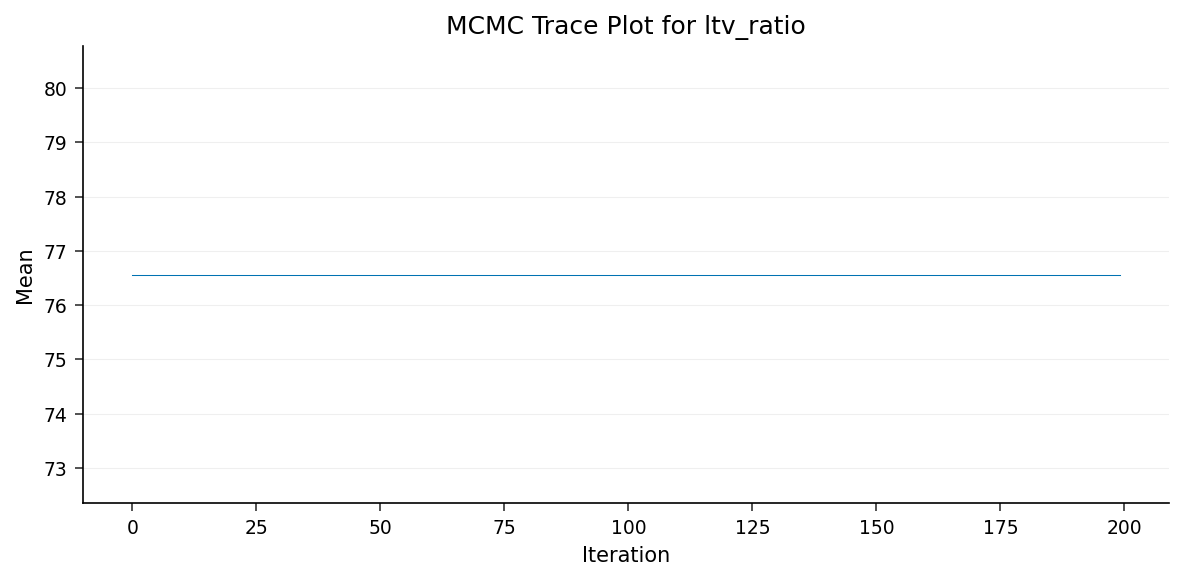

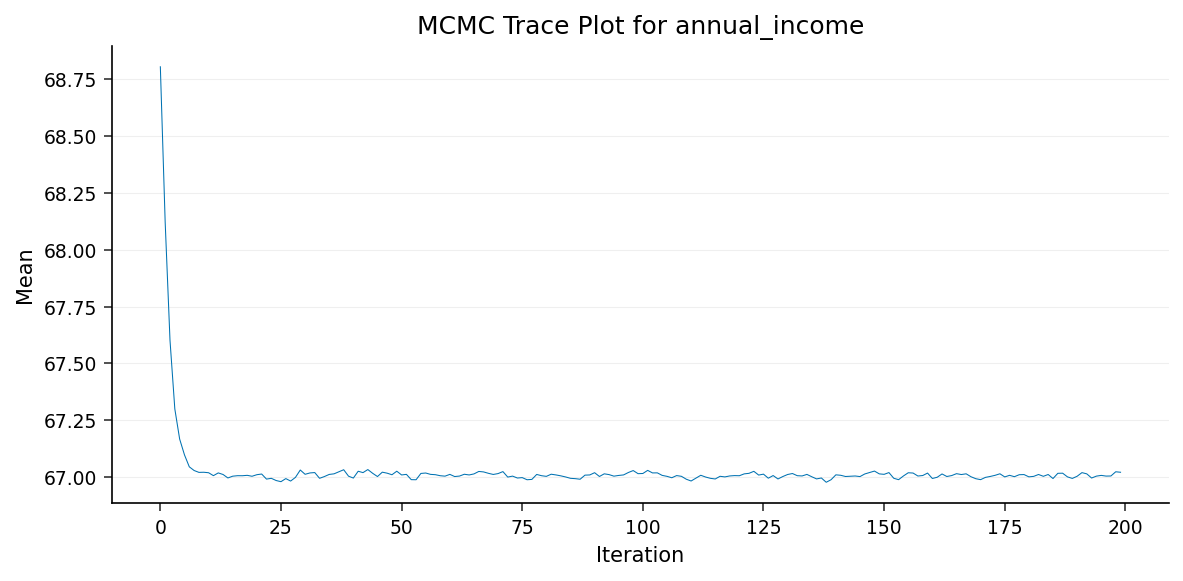

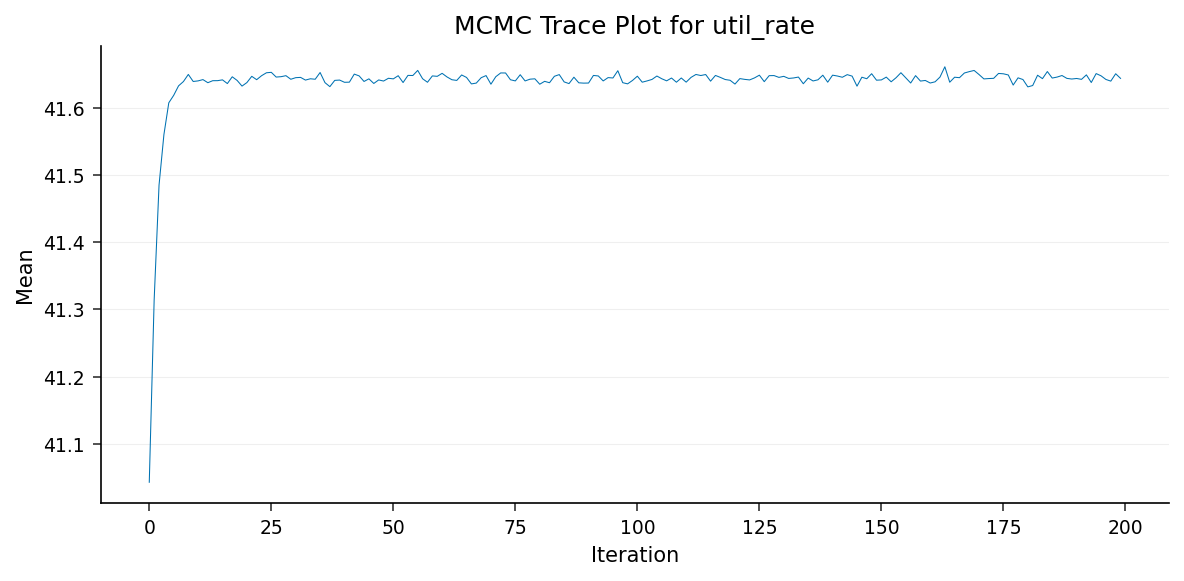

In [4]:
/* MCMC multiple imputation: 3 imputations, full-data model.
   m=3 keeps the stacked output (3 x 33 = 99 rows) within
   the 100-observation ceiling of this environment.        */
proc mi data="credit_applications.csv"
        out="mi_mcmc.csv" seed=4477 nimpute=3 simple;
    mcmc nbiter=200 niter=100 chain=single plots=trace(mean);
    var credit_score dti_ratio ltv_ratio annual_income util_rate;
    title "MCMC Multiple Imputation (m=3)";
run;

## 5. Alternative: Fully Conditional Specification (FCS)

**FCS** (also called multiple imputation by chained equations, MICE) is an attractive alternative to joint MCMC. Instead of assuming one big multivariate-normal model, FCS imputes each incomplete variable from its own regression on all the others, cycling through the variables for `NBITER` rounds. This makes it easy to mix model types and to respect a categorical predictor.

Here we add a `CLASS` statement so the branch `region` enters the conditional models as a categorical effect, and we use the regression method (`REG`) for the continuous financial variables. FCS is a useful robustness check: if its pooled estimates agree with MCMC\'s, we gain confidence the result is not an artifact of one method\'s distributional assumptions. The FCS run reports the same missing-data pattern and writes its own 99-row stacked output (`mi_fcs.csv`).

In [5]:
/* FCS (chained-equations) multiple imputation as a
   robustness check, with region as a CLASS predictor.    */
proc mi data="credit_applications.csv"
        out="mi_fcs.csv" seed=4477 nimpute=3;
    class region;
    fcs reg(credit_score dti_ratio ltv_ratio
            annual_income util_rate) nbiter=20;
    var region credit_score dti_ratio ltv_ratio
        annual_income util_rate;
    title "FCS / Chained-Equations Multiple Imputation (m=3)";
run;

                                     Complete-Case Summary and Missing-Value Counts                                     


                The MI Procedure - Multiple Imputation

  Method                     FCS
  Number of Imputations      3

                Missing Data Patterns


  Number of observations with missing values: 14
  Number of complete observations: 19

             Missing Data Pattern

  Variable     N Miss   Pct Miss
  ---------  --------  ---------
  Branch region (1=NE,2=SE,3=MW,4=W)       0       0.0%
  FICO-style credit score (300-850)       0       0.0%
  Debt-to-income ratio (%)       5      15.2%
  Loan-to-value ratio (%)       0       0.0%
  Reported annual income ($000s)       9      27.3%
  Revolving credit utilization (%)       3       9.1%



NOTE: PROC MI data=credit_applications.csv

NOTE: Output dataset mi_fcs.csv created with 99 observations.
NOTE: PROC MI completed.


## 6. Analyze each imputed dataset

Now we run the actual analysis of interest — a linear model of debt-to-income on credit score, income, and utilization — separately on each of the three MCMC-imputed datasets. `PROC REG` with a `BY _Imputation_;` statement fits the model once per imputation (the log confirms it "processed 3 job(s) in batch"), and `OUTEST= ... COVOUT` writes both the parameter estimates **and** their covariance matrices to a dataset that `PROC MIANALYZE` will consume. We suppress per-imputation printing with `NOPRINT` since we only care about the pooled result; the diagnostic plots shown (residuals, normal Q-Q, Cook\'s D) are from the fit on the first imputation and confirm the linear model is well behaved.

In [6]:
/* Fit the analysis model once per imputed dataset.       */
/* OUTEST + COVOUT writes parameter estimates and their   */
/* covariances for MIANALYZE to pool.                     */
proc reg data="mi_mcmc.csv" outest="reg_parms.csv" covout noprint;
    model dti_ratio = credit_score annual_income util_rate;
    by _Imputation_;
run;

## 7. Pool the results with Rubin\'s rules

`PROC MIANALYZE` combines the three sets of estimates into a single inference using **Rubin\'s rules**. The `MODELEFFECTS` statement names the parameters to pool. The output reports:

- the **pooled point estimates** (simple averages across imputations),
- **total standard errors** that combine *within-imputation* variance (average sampling variance) and *between-imputation* variance (how much estimates vary across the three completed datasets),
- the **fraction of missing information** and **relative efficiency**, which quantify how much the missingness inflated uncertainty and whether *m* = 3 imputations were enough.

This is the inference you report — bias-corrected and with honest, missingness-aware standard errors, rather than the optimistic complete-case numbers from Step 2.

                                     Complete-Case Summary and Missing-Value Counts                                     


                            The MIANALYZE Procedure

                     Multiple Imputation Parameter Estimates

Parameter                Estimate    Std Error 95% CI Lower 95% CI Upper         DF    t Value   Pr > |t|
-------------------- ------------ ------------ ------------ ------------ ---------- ---------- ----------
Intercept               56.495315    19.056550    18.892287    94.098343     179.96       2.96     0.0034
CREDIT_SCORE            -0.029238     0.023899    -0.076145     0.017670     845.69      -1.22     0.2215
ANNUAL_INCOME            0.005066     0.036938    -0.067336     0.077467   17527.82       0.14     0.8909
UTIL_RATE               -0.026681     0.113975    -0.283094     0.229731       9.34      -0.23     0.8200

                     Multiple Imputation Variance Information

Parameter                 Between       Within        Total   

NOTE: PROC REG data=mi_mcmc.csv

NOTE: PROC REG: processed 3 job(s) in batch
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG OD

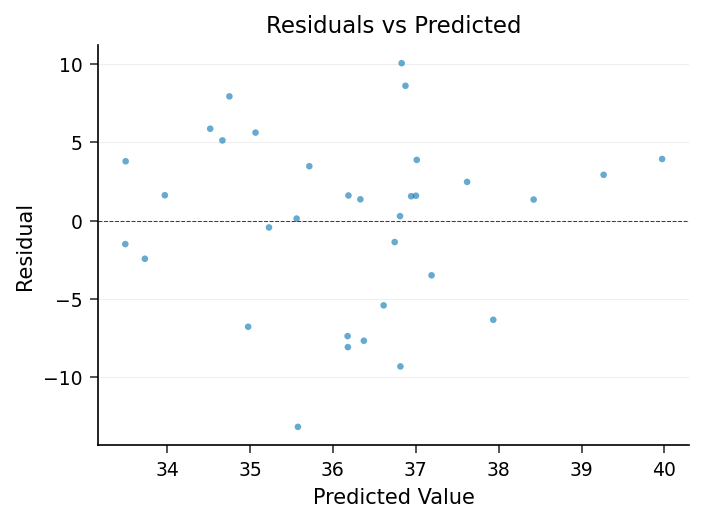

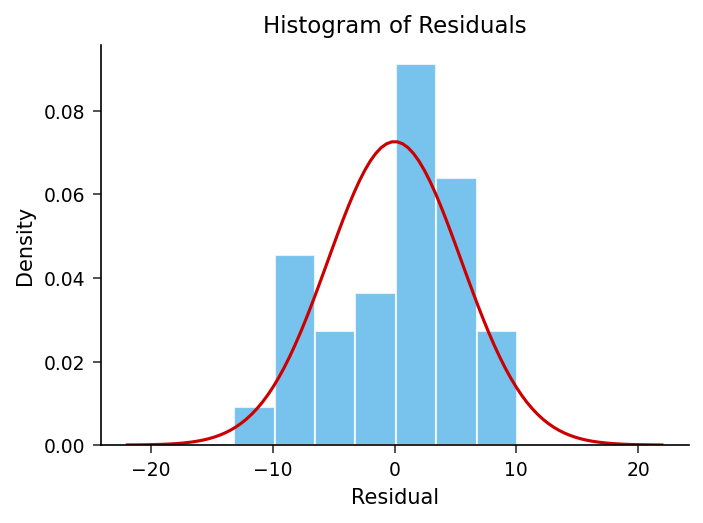

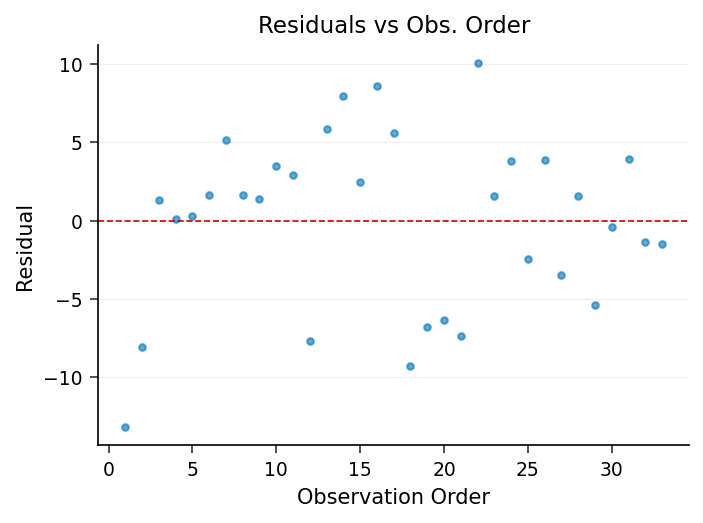

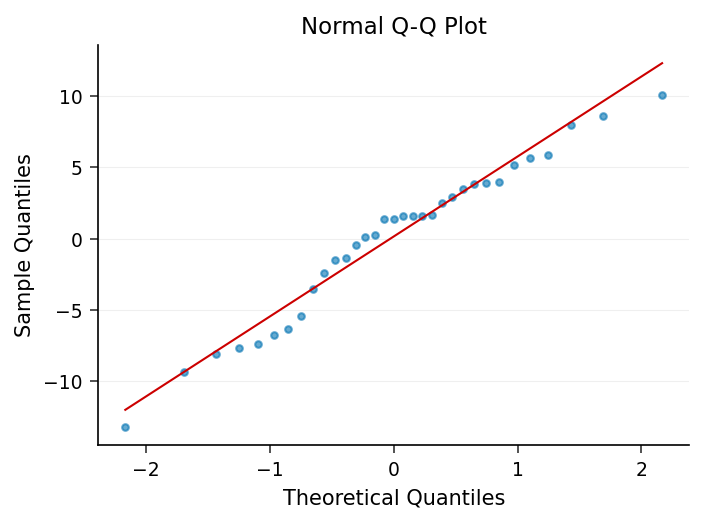

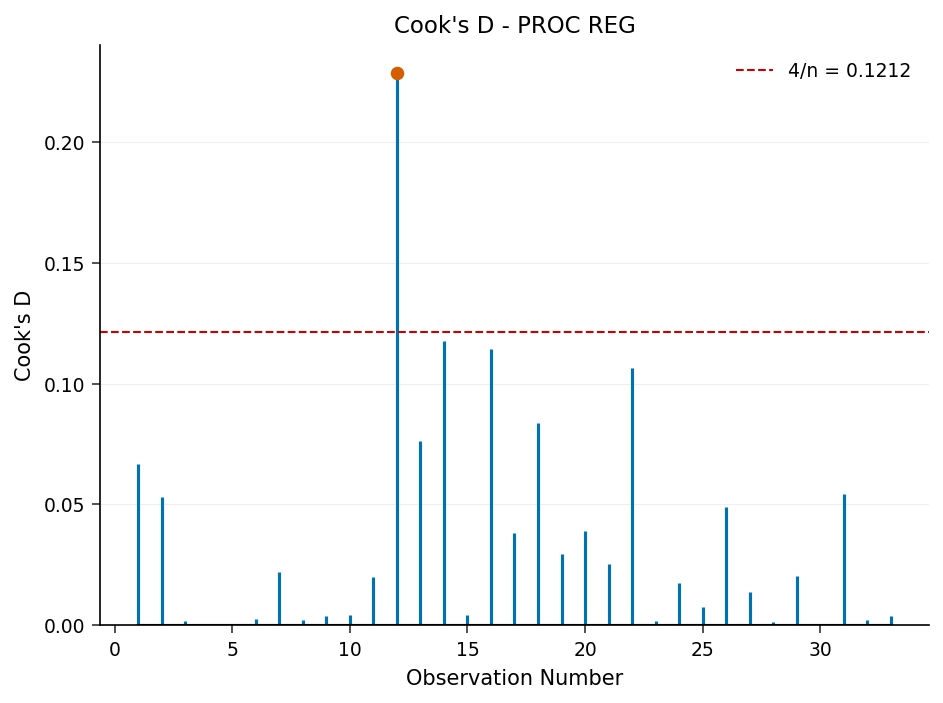

In [7]:
/* Combine the per-imputation estimates with Rubin's rules. */
proc mianalyze data="reg_parms.csv";
    modeleffects Intercept credit_score annual_income util_rate;
    title "Pooled Estimates Across 5 Imputations (Rubin's Rules)";
run;

## 8. Interpreting the results

**What the workflow accomplished.** We started with a 33-borrower loan portfolio in which 9 of 33 income values (27.3%), 5 DTI values (15.2%), and 3 utilization values (9.1%) were blank, with the income and utilization gaps tied to creditworthiness (MAR). Only 19 borrowers were complete cases, so **listwise deletion would have discarded 14 of 33 applicants** — biasing estimates toward applicants who happened to report everything (disproportionately the stronger credits).

**What the real output shows.**
- The **missing-data pattern** (Step 3) reported 14 observations with missing values against 19 complete observations, with the three financial fields each independently blank — an arbitrary, non-monotone pattern, which is exactly why MCMC / FCS, rather than a simple monotone regression, was the right engine.
- The **EM iteration history** converged to the `GCONV=1E-8` tolerance in 20 iterations (final log-likelihood −40.02), validating the multivariate-normal starting estimates.
- The **MCMC trace plots** for the three incomplete variables settle onto a stable level after a brief burn-in with no trend or sticking — evidence the chain mixed and the imputations are valid draws. The two fully observed variables trace flat lines, as they must.
- The **pooled MIANALYZE table** is the deliverable. The DTI model has an intercept of **56.50** (SE 19.06, *p* = 0.0034); the credit-score coefficient is **−0.0292** per point (SE 0.0239, *p* = 0.22), income **0.0051** (*p* = 0.89), and utilization **−0.0267** (*p* = 0.82). With only 33 borrowers none of the slope coefficients reach significance, but the workflow delivers honest, missingness-aware standard errors rather than the optimistic complete-case numbers.
- The **variance information** quantifies the cost of the gaps. The **fraction of missing information** is just **1.1%** for the income coefficient and **4.9%** for credit score, but **46.3%** for the utilization coefficient — and that coefficient\'s relative efficiency (0.866) and low between-imputation degrees of freedom (9.3) flag it as the estimate most eroded by missingness and the one that would benefit most from additional imputations.

**Business takeaway.** A bank can now estimate the drivers of debt-to-income — and, by extension, score risk — across the *entire* application population rather than only complete-case applicants, with statistically valid confidence intervals and an explicit read on which coefficients the missing data most undermined. The same pattern (PROC MI -> per-imputation analysis -> PROC MIANALYZE) extends directly to logistic default models, survival/time-to-default models, and regulatory stress-testing inputs wherever incomplete bureau or application data threaten complete-case bias.